In [34]:
from sklearn.datasets import load_diabetes

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [35]:
X,y = load_diabetes(return_X_y=True)

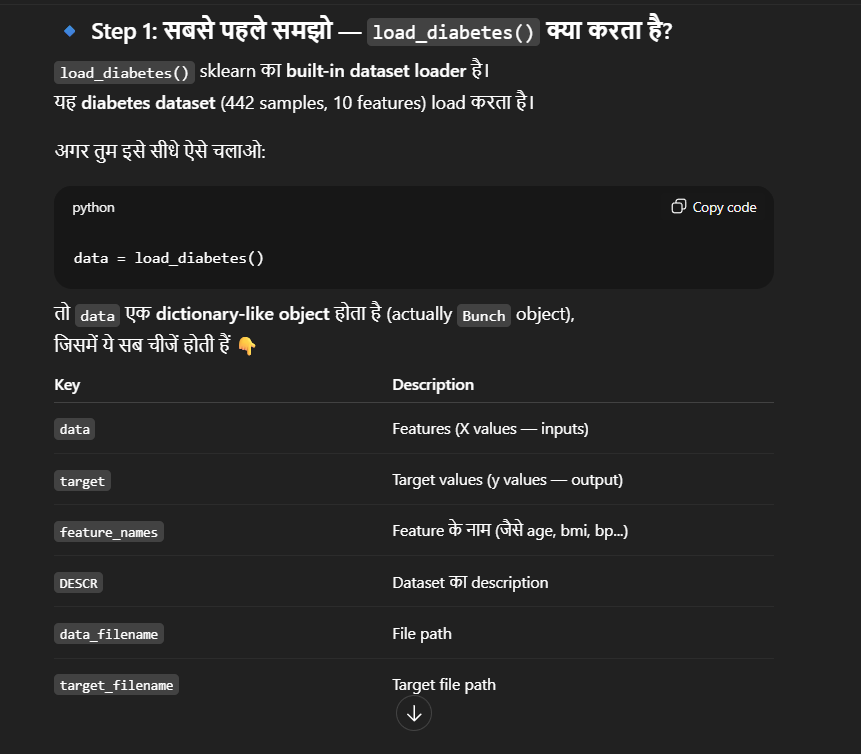

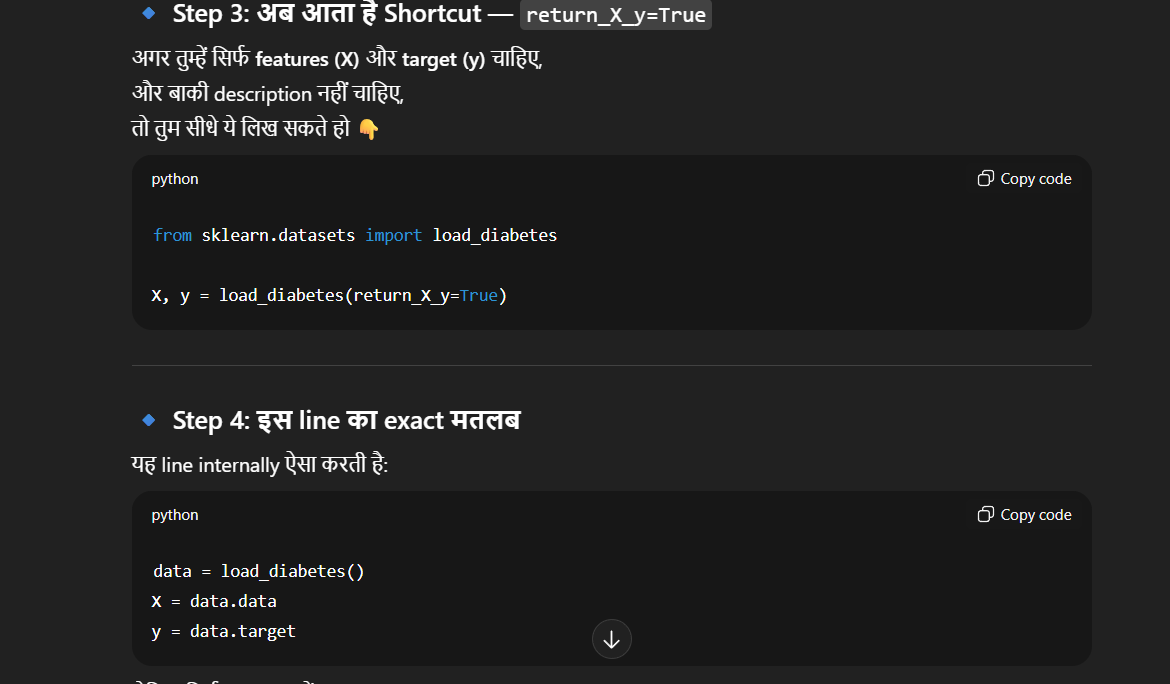

In [36]:
print(X.shape)
print(y.shape)


(442, 10)
(442,)


In [37]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)
# “Randomness को control करना ताकि हर बार result same रहे।”

In [38]:
reg = LinearRegression()  # यह line Linear Regression model का object बनाती है।
reg.fit(X_train,y_train)

LinearRegression()

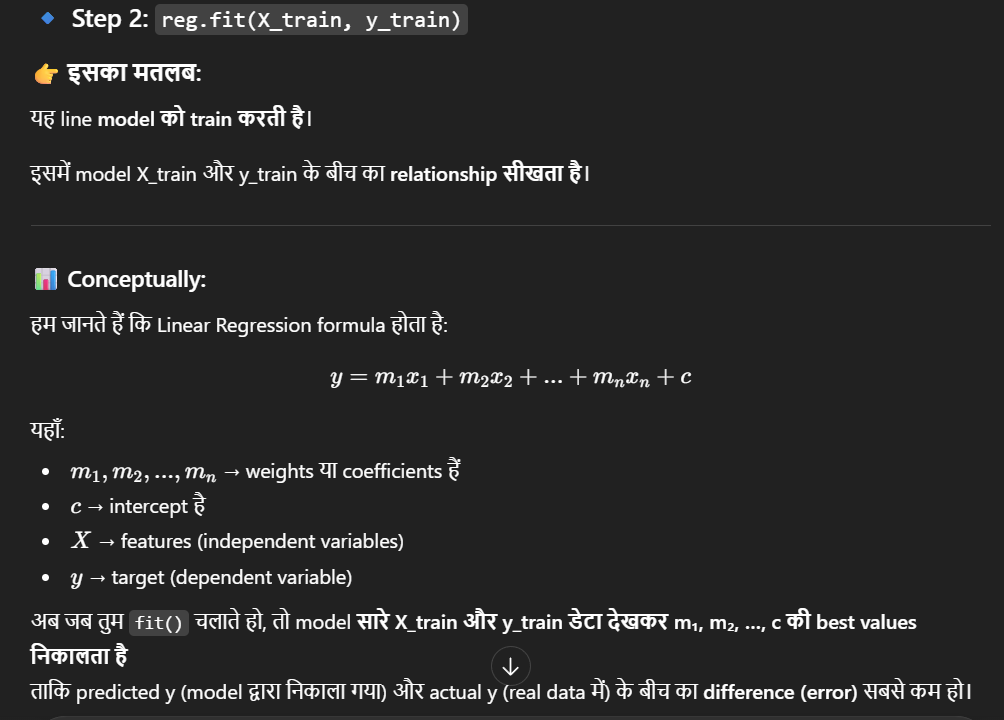

In [39]:
LinearRegression()

LinearRegression()

In [40]:
X.shape

(442, 10)

In [41]:
y.shape

(442,)

In [42]:
print(reg.coef_)
print(reg.intercept_)

[  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
  561.22067904  153.89310954  126.73139688  861.12700152   52.42112238]
151.88331005254167


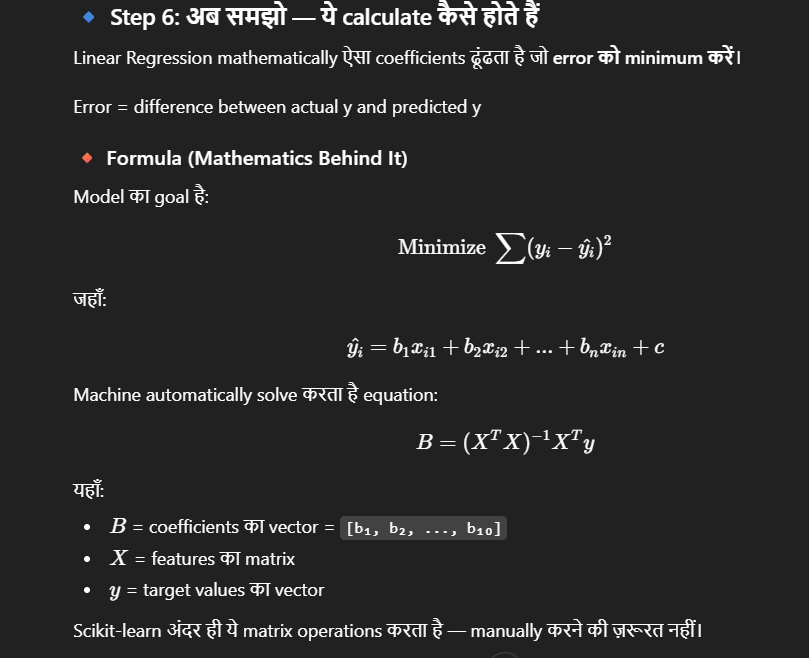

In [43]:
y

array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
        69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
        68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
        87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
       259.,  53., 190., 142.,  75., 142., 155., 225.,  59., 104., 182.,
       128.,  52.,  37., 170., 170.,  61., 144.,  52., 128.,  71., 163.,
       150.,  97., 160., 178.,  48., 270., 202., 111.,  85.,  42., 170.,
       200., 252., 113., 143.,  51.,  52., 210.,  65., 141.,  55., 134.,
        42., 111.,  98., 164.,  48.,  96.,  90., 162., 150., 279.,  92.,
        83., 128., 102., 302., 198.,  95.,  53., 134., 144., 232.,  81.,
       104.,  59., 246., 297., 258., 229., 275., 281., 179., 200., 200.,
       173., 180.,  84., 121., 161.,  99., 109., 115., 268., 274., 158.,
       107.,  83., 103., 272.,  85., 280., 336., 281., 118., 317., 235.,
        60., 174., 259., 178., 128.,  96., 126., 28

In [44]:
y_pred = reg.predict(X_test)
y_pred

array([154.1213881 , 204.81835118, 124.93755353, 106.08950893,
       258.5348576 , 256.3310074 , 118.75087616, 119.52440696,
       101.50816735, 190.54048661, 141.70656811, 172.51883961,
       174.33861649, 134.80942706, 294.13994537,  94.11798038,
       211.97059795, 156.49579378, 134.21000428, 119.62664644,
       148.87842251, 165.00873409, 151.10021038, 176.04063756,
       133.27769647, 221.29555392, 197.17324941,  96.1577688 ,
        50.26012711, 230.48580317, 242.06073866, 114.11129218,
        67.07532417,  94.52943825, 201.21415375, 167.05136201,
       159.881268  , 192.78746659, 114.49551325, 233.48234551,
       140.82563045, 121.0680409 , 192.27480772, 191.12738845,
       179.16865788, 148.34935601, 163.47414622, 276.81647884,
       100.17926432, 164.10555298, 255.80762189, 136.9466204 ,
       152.37503699, 107.92237882, 194.21924678,  77.34670792,
       118.50482479,  68.38335763, 154.29258529, 162.48840259,
       168.36788326, 156.87790322,  97.14191797, 238.16

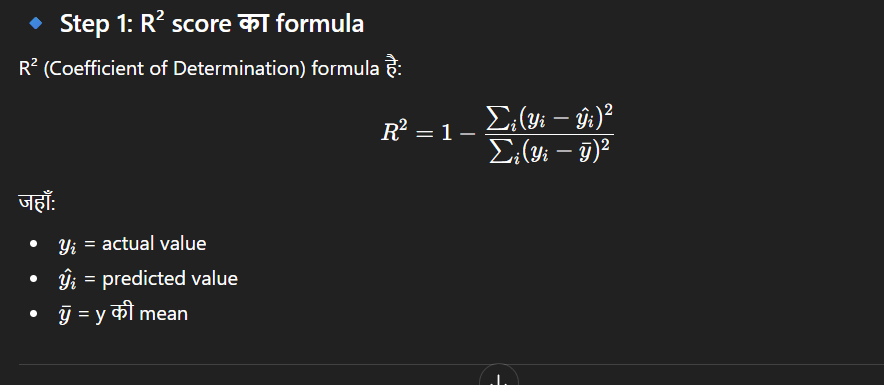

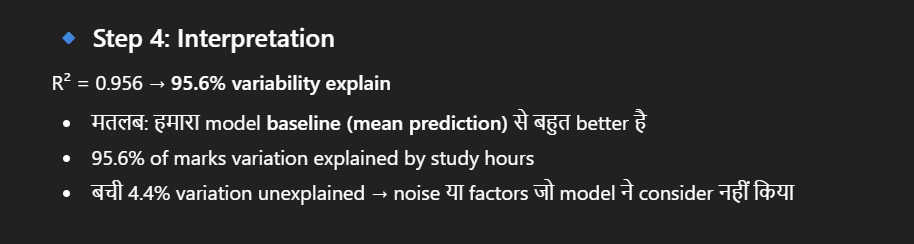

In [45]:
X_train.shape

(353, 10)

In [56]:
class GDRegressor:
    
    def __init__(self,learning_rate=0.01,epochs=100):
        
        self.coef_ = None
        self.intercept_ = None
        self.lr = learning_rate
        self.epochs = epochs
        
    def fit(self,X_train,y_train):
        # init your coefs
        self.intercept_ = 0  # pahle ham intercept ko 0 se initialize kar dete hain 
        self.coef_ = np.ones(X_train.shape[1]) # data me jitne colmn honge utne hi coeff honge 
                                               # jitne no of col hote hai utne hi no of coeff hote hai 
        for i in range(self.epochs):
            # update all the coef and the intercept
            y_hat = np.dot(X_train,self.coef_) + self.intercept_  # beta1 beta2 ko hi coeff hai 
            #print("Shape of y_hat",y_hat.shape)
            intercept_der = -2 * np.mean(y_train - y_hat) # y_hat hi y_pred hai 
            self.intercept_ = self.intercept_ - (self.lr * intercept_der)
            
            coef_der = -2 * np.dot((y_train - y_hat),X_train)/X_train.shape[0]
            self.coef_ = self.coef_ - (self.lr * coef_der)
        
        print(self.intercept_,self.coef_)
    
    def predict(self,X_test):
        return np.dot(X_test,self.coef_) + self.intercept_

#### ye intercept ke derivative hai 

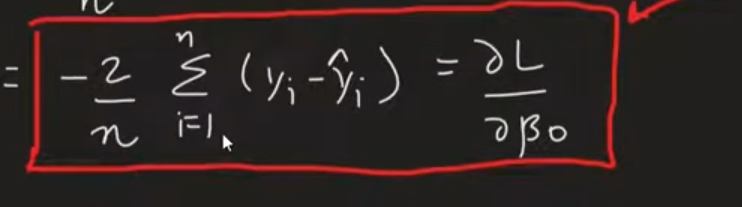

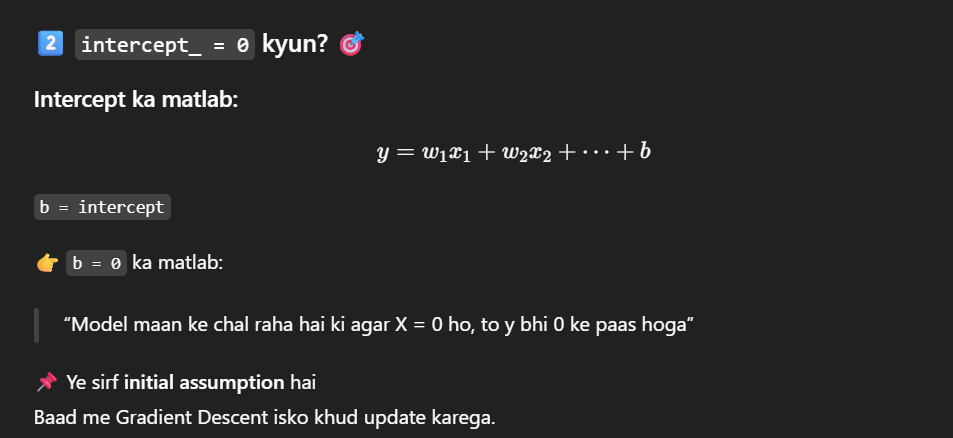

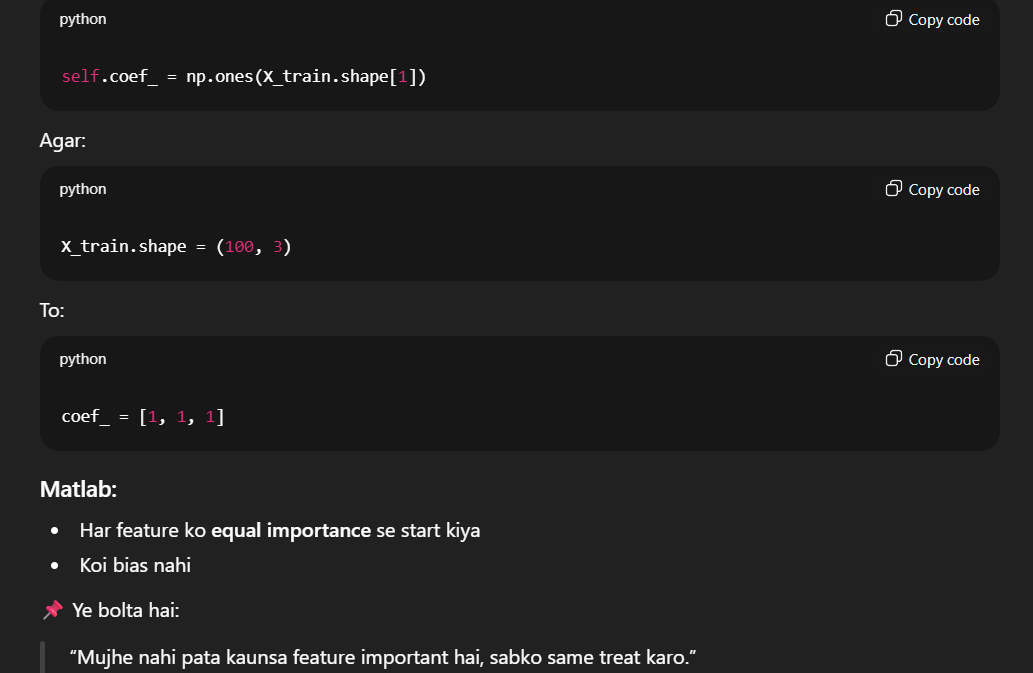

In [57]:
 np.ones(X_train.shape[1])

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

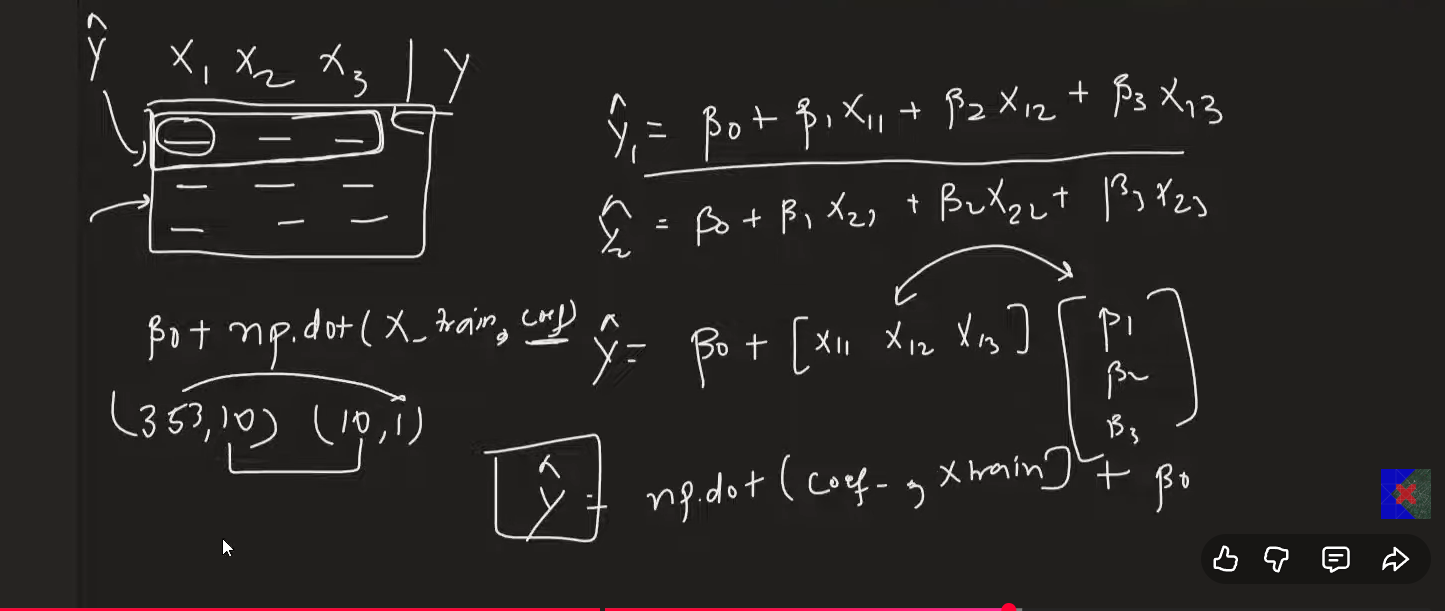

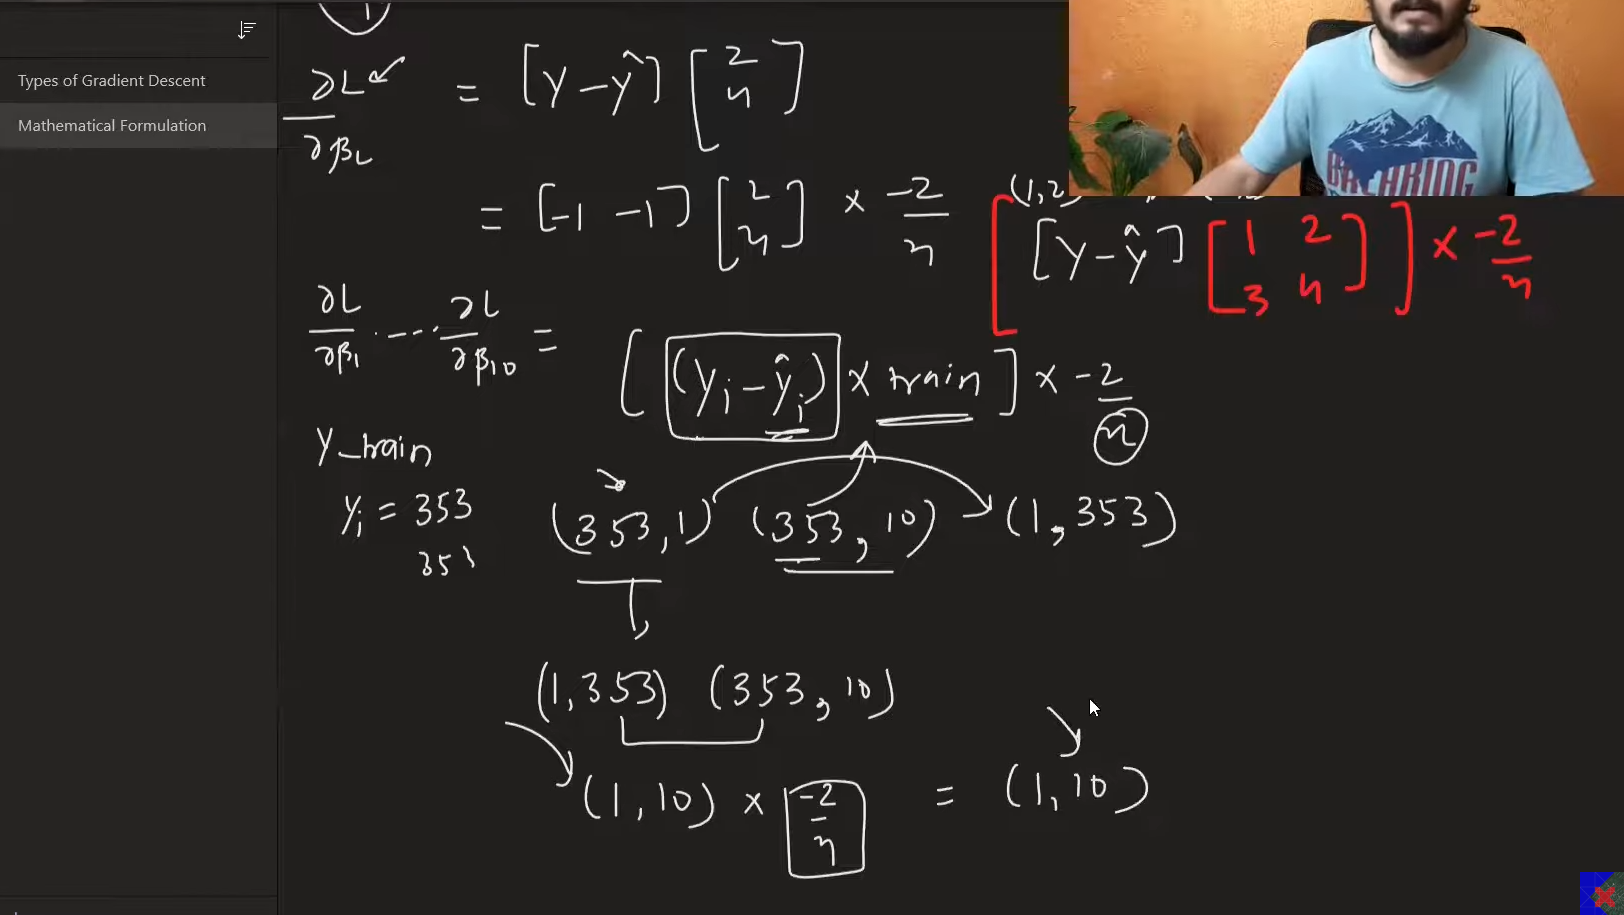

In [62]:
gdr = GDRegressor(epochs=1000,learning_rate=0.5)

In [63]:

gdr.fit(X_train,y_train)

152.01351687661833 [  14.38990585 -173.7235727   491.54898524  323.91524824  -39.32648042
 -116.01061213 -194.04077415  103.38135565  451.63448787   97.57218278]


In [64]:
# [  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
#   561.22067904  153.89310954  126.73139688  861.12700152   52.42112238]
# 151.88331005254167

In [65]:

y_pred = gdr.predict(X_test)
y_pred

array([152.26392304, 198.96222354, 127.66111541, 104.59596478,
       265.23062371, 252.09467525, 112.76592254, 115.72549839,
        96.37765691, 187.64845451, 144.9482918 , 172.110596  ,
       178.81497695, 136.51444368, 292.15564227,  87.25795061,
       202.18473262, 149.11155912, 132.30895031, 128.70828962,
       148.38757935, 171.81318343, 150.93593445, 174.47559507,
       127.76388814, 221.82234243, 199.96855698, 101.54518353,
        54.85644772, 237.61948938, 244.2801351 , 112.91877003,
        68.12192242,  96.00468527, 204.32975531, 163.99882781,
       160.95172334, 191.90398957, 113.33794145, 238.46002509,
       141.40211434, 120.45598718, 188.12639096, 186.46474321,
       174.98259299, 143.24561624, 168.80798895, 299.18508813,
       105.40854525, 169.51466009, 254.37509674, 142.60026818,
       151.7158263 , 122.70403085, 191.52875115,  94.27792144,
       129.03875584,  75.96073902, 157.91752518, 156.36603694,
       163.20324594, 160.93274887, 102.3002858 , 227.76

In [66]:
r2_score(y_test,y_pred)

0.4534503034722803